# Lab 1 · EDA and simple baselines
Pairs · 24 September 2026, 12:30 Santiago · 6% NP.
Read the brief and rubric first. Supplied code supports execution; replace the written prompts and add your own analysis cells. MODE="synthetic" is fictional practice only. Real submission uses snapshot.

In [42]:
from pathlib import Path
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for p in (Path.cwd(), *Path.cwd().parents):
    if (p/'labs/lab_01/lab01_support_v1.py').exists():
        ROOT=p; break
else:
    raise FileNotFoundError('Extract the full package and run inside it.')
sys.path.insert(0,str(ROOT/'labs/lab_01'))
from lab01_support_v1 import load_sources,merge_sources,majority_from_train,evaluate
MODE="snapshot"
print('DATA MODE:', MODE, '| Python:',platform.python_version(),'| pandas:',pd.__version__)

DATA MODE: snapshot | Python: 3.14.3 | pandas: 2.3.1


## 1. Target and audit
State the prediction moment, unit, population and target. Distinguish final classification from completing a race. Explain the source limitations. TO COMPLETE.

In [43]:
q_train,r_train=load_sources('train',ROOT,MODE)
train=merge_sources(q_train,r_train)
display(pd.DataFrame({'qualifying':q_train.groupby('season').size(),'results':r_train.groupby('season').size()}))
display(train.groupby('season').agg(rows=('driver_id','size'),missing_qualifying=('qualifying_position',lambda x:x.isna().sum())))
assert len(train)==len(r_train)
display(train['qualifying_match'].value_counts())

C:\Users\Agustin\AppData\Roaming\Python\Python314\site-packages\pandas\core\reshape\merge.py:935: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  left["_left_indicator"] = left["_left_indicator"].astype("int8")
C:\Users\Agustin\AppData\Roaming

,qualifying,results
season,,
2019,418,420
2020,340,340
2021,439,440


,rows,missing_qualifying
season,,
2019,420,2
2020,340,0
2021,440,1


qualifying_match
both          1197
left_only        3
right_only       0
Name: count, dtype: int64

Add checks for duplicate keys, qualifying-only records, missing values and coverage. Explain what would happen with an inner join. TO COMPLETE.

In [140]:
duplicates = train.duplicated().sum()
null_cols = train.columns[train.isna().any()]
count_rows = train.shape[0]

print(f"Number of duplicate rows: {duplicates}")
print(f"Columns with missing values: {null_cols.tolist()}")
print(f"Total number of rows in the dataset: {count_rows}")

Number of duplicate rows: 0
Columns with missing values: ['qualifying_position']
Total number of rows in the dataset: 1200


We analized the dataset and we decided to drop the rows, a

## 2. EDA question 1
Question: How well does qualifying position anticipate a top-ten finish?

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

,Drivers,Finished top 10,Top-10 rate
Qualifying position,,,
1,60,57,95.0%
2,60,52,86.7%
3,60,50,83.3%
4,60,52,86.7%
5,60,44,73.3%
6,60,45,75.0%
7,60,43,71.7%
8,60,34,56.7%
9,60,40,66.7%


Rows without qualifying (excluded from this table): 3


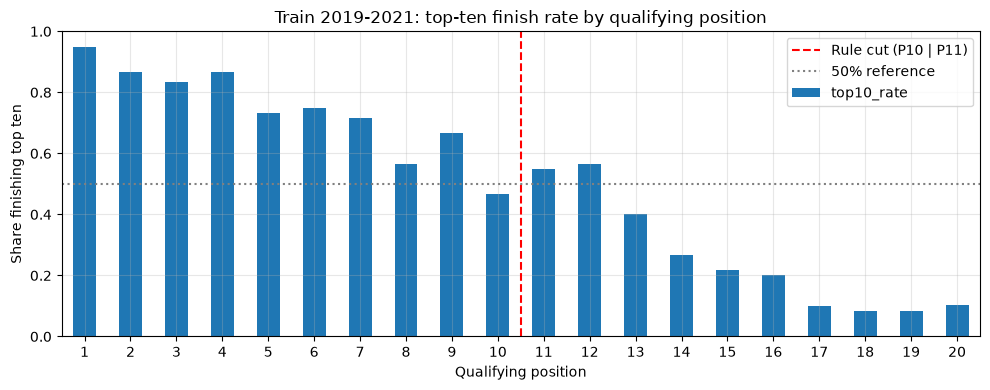

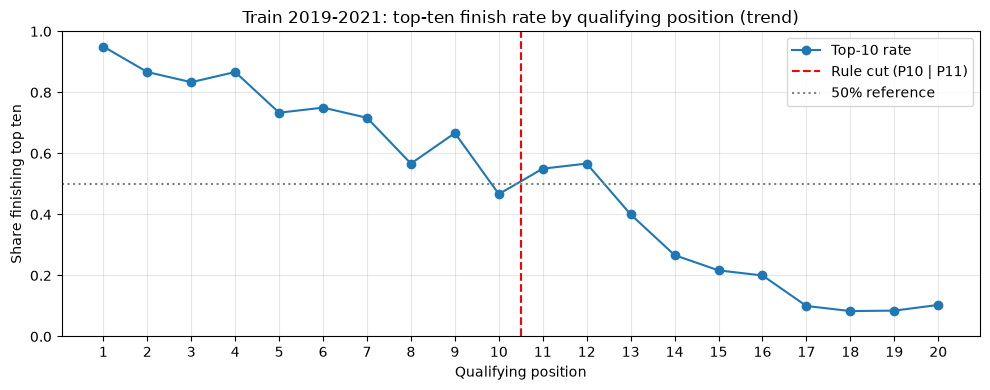

In [157]:
## Q1: top-ten rate for each qualifying position (train 2019-2021 only)
stats_q1 = (train
            .groupby('qualifying_position')['target_top10']
            .agg(drivers='count', finished_top10='sum', top10_rate='mean'))
stats_q1.index = stats_q1.index.astype(int)

## readable copy for display only, the numeric one stays for the chart
table_q1 = stats_q1.copy()
table_q1.index.name = 'Qualifying position'
table_q1['top10_rate'] = (table_q1['top10_rate'] * 100).round(1).astype(str) + '%'
table_q1.columns = ['Drivers', 'Finished top 10', 'Top-10 rate']
display(table_q1)

## groupby drops NaN keys, so the 3 rows without qualifying are NOT in this table
n_missing_quali = train['qualifying_position'].isna().sum()
print(f"Rows without qualifying (excluded from this table): {n_missing_quali}")

## bar chart: y fixed 0-1 so the drop isn't exaggerated, dashed line = the rule's cut
fig, ax = plt.subplots(figsize=(10, 4))
stats_q1['top10_rate'].plot(kind='bar', ax=ax, color='#1f77b4')
ax.axvline(9.5, color='red', linestyle='--', label='Rule cut (P10 | P11)')
ax.axhline(0.5, color='gray', linestyle=':', label='50% reference')
ax.set_ylim(0, 1)
ax.set_xlabel('Qualifying position')
ax.set_ylabel('Share finishing top ten')
ax.set_title('Train 2019-2021: top-ten finish rate by qualifying position')
ax.tick_params(axis='x', rotation=0)  ## keeps position labels horizontal
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## line chart: same data, easier to see the overall trend across positions
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(stats_q1.index, stats_q1['top10_rate'], marker='o', color='#1f77b4', label='Top-10 rate')
ax.axvline(10.5, color='red', linestyle='--', label='Rule cut (P10 | P11)')
ax.axhline(0.5, color='gray', linestyle=':', label='50% reference')
ax.set_xticks(stats_q1.index)  ## show every position 1-20 on the x-axis
ax.set_ylim(0, 1)
ax.set_xlabel('Qualifying position')
ax.set_ylabel('Share finishing top ten')
ax.set_title('Train 2019-2021: top-ten finish rate by qualifying position (trend)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [155]:
# on position 19 and 20, there are 59 and 58 drivers, this is because the dataset contained nulls in qualifying_position, which were dropped by the groupby. The remaining 3 rows without qualifying are not included in this table.

## 3. EDA question 2
Question: Does the training majority change if the rows with missing qualifying positions are dropped?

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

In [141]:
# First search missing columns in the train dataset
missing_columns_train = train.columns[train.isna().any()].tolist()
print(f"Missing columns in train dataset: {missing_columns_train}")
#Next, we see how many missing values are in the qualifying_position column
missing_qualifying_position = train['qualifying_position'].isna().sum()
print(f"Number of missing values in 'qualifying_position' column: {missing_qualifying_position}")
overall_null_percentage = train.isna().to_numpy().mean() * 100
print(f"Overall percentage of null cells in the entire dataset: {overall_null_percentage:.2f}%")

# Create a filtered copy; keep the original train dataset unchanged
train_without_missing = train[
    train["qualifying_position"].notna()
].copy()

# Compare both populations
comparison = pd.DataFrame({
    "dataset": [
        "All train rows",
        "Missing qualifying rows dropped"
    ],
    "number_of_rows": [
        len(train),
        len(train_without_missing)
    ],
    "missing_qualifying": [
        train["qualifying_position"].isna().sum(),
        train_without_missing["qualifying_position"].isna().sum()
    ],
    "target_top10_rate": [
        train["target_top10"].mean(),
        train_without_missing["target_top10"].mean()
    ],
    "training_majority": [
        majority_from_train(train),
        majority_from_train(train_without_missing)
    ]
})

comparison["target_top10_rate"] = (
    comparison["target_top10_rate"] * 100
).round(2)

display(comparison)



Missing columns in train dataset: ['qualifying_position']
Number of missing values in 'qualifying_position' column: 3
Overall percentage of null cells in the entire dataset: 0.01%


C:\Users\Agustin\AppData\Local\Temp\ipykernel_14220\1408530447.py:39: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  comparison["target_top10_rate"] = (


,dataset,number_of_rows,missing_qualifying,target_top10_rate,training_majority
0,All train rows,1200,3,50.00,0
1,Missing qualifying rows dropped,1197,0,50.04,1


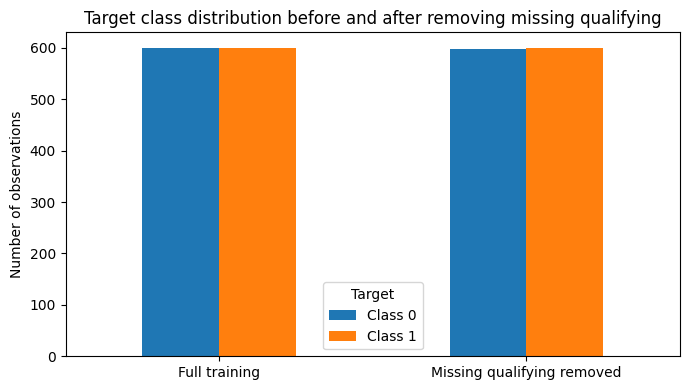

In [ ]:
# Compare class distribution before and after removing missing qualifying positions

class_comparison = pd.DataFrame({
    "Class 0": [
        (train["target_top10"] == 0).sum(),
        (train_without_missing["target_top10"] == 0).sum()
    ],
    "Class 1": [
        (train["target_top10"] == 1).sum(),
        (train_without_missing["target_top10"] == 1).sum()
    ]
}, index=["Full training", "Missing qualifying removed"])

ax = class_comparison.plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_xlabel("")
ax.set_ylabel("Number of observations")
ax.set_title("Target class distribution before and after removing missing qualifying")
ax.legend(title="Target")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

There are 3 observations with a missing qualifying_position in the training data. To determine whether these observations affect the training-majority baseline, we compare the target distribution before and after removing them.

The complete training set contains 1,200 observations, with 600 belonging to the positive class (target_top10 = 1) and 600 to the negative class (target_top10 = 0). Therefore, the classes are exactly balanced, and according to the baseline definition, the training majority is 0 in case of a tie.

After removing the 3 observations with missing qualifying positions, the class distribution changes slightly. However, class 0 remains the majority, so the training-majority baseline does not change.

The 3 observations with missing qualifying positions have a lower observed top-10 rate than the observations with a valid qualifying position. However, this difference is based on only 3 observations, so it should not be generalized.

Therefore, removing rows with missing qualifying positions would not affect the majority baseline in this training set. Nevertheless, we keep these observations because the dataset should preserve the full results population, and the baseline using qualifying position can handle missing values by falling back to the training majority.

## 4. EDA question 3
Question: Are Grid and Qualifying position the same number? Do they match?

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

,Rows,Grid = qualifying,Grid != qualifying,Pit-lane starts (grid 0),Cross the P10 cut
Train 2019-2021,1197,816,381,28,53


Grid top 10,False,True
Qualifying top 10,,
False,571,26
True,27,573


,,drivers,finished_top10
quali_top10,grid_top10,,
False,True,26,18
True,False,27,9


,season,round,driver_id,qualifying_position,grid,position,status
37,2019,2,ricciardo,11.0,10,18,Out of fuel
39,2019,2,grosjean,8.0,11,20,Retired
71,2019,4,giovinazzi,8.0,17,12,+1 Lap
79,2019,4,ricciardo,11.0,10,20,Collision
91,2019,5,ricciardo,10.0,13,12,Finished
99,2019,5,norris,11.0,10,20,Collision
124,2019,7,max_verstappen,11.0,9,5,Finished
129,2019,7,kvyat,12.0,10,10,+1 Lap
130,2019,7,sainz,9.0,11,11,+1 Lap
136,2019,7,kevin_magnussen,10.0,0,17,+2 Laps


Correlation qualifying vs grid: 0.87


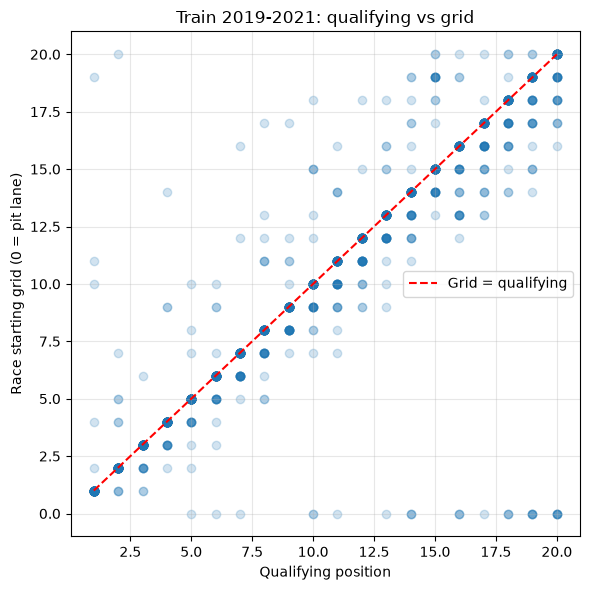

In [160]:
## Q3: does the race starting grid match qualifying position? (train only, EDA)
## only rows with a qualifying record, the 3 NaN rows can't be compared
has_quali = train.dropna(subset=['qualifying_position']).copy()

has_quali['same_position'] = has_quali['grid'] == has_quali['qualifying_position']
has_quali['pit_lane_start'] = has_quali['grid'] == 0  ## grid 0 = started from the pit lane

## side of the P10 cut for each source (grid 0 counts as outside the top ten)
has_quali['quali_top10'] = has_quali['qualifying_position'] <= 10
has_quali['grid_top10'] = has_quali['grid'].between(1, 10)
has_quali['crosses_cut'] = has_quali['quali_top10'] != has_quali['grid_top10']

summary_q3 = pd.DataFrame({
    'Rows'                     : [len(has_quali)],
    'Grid = qualifying'        : [has_quali['same_position'].sum()],
    'Grid != qualifying'       : [(~has_quali['same_position']).sum()],
    'Pit-lane starts (grid 0)' : [has_quali['pit_lane_start'].sum()],
    'Cross the P10 cut'        : [has_quali['crosses_cut'].sum()],
}, index=['Train 2019-2021'])
display(summary_q3)

## which side of the cut each driver was on, by qualifying vs by grid
table_cut = pd.crosstab(has_quali['quali_top10'], has_quali['grid_top10'],
                        rownames=['Qualifying top 10'], colnames=['Grid top 10'])
display(table_cut)

## for the rows that cross the cut: what actually happened in the race?
crossers = has_quali[has_quali['crosses_cut']]
table_crossers = (crossers
                  .groupby(['quali_top10', 'grid_top10'])['target_top10']
                  .agg(drivers='count', finished_top10='sum'))
display(table_crossers)

## a few concrete cases to cite in the interpretation
display(crossers[['season', 'round', 'driver_id', 'qualifying_position',
                  'grid', 'position', 'status']].head(10))

## Q3 chart: qualifying position vs race grid
corr = has_quali['qualifying_position'].corr(has_quali['grid'])
print(f"Correlation qualifying vs grid: {corr:.2f}")

plt.figure(figsize=(6, 6))
plt.scatter(has_quali['qualifying_position'], has_quali['grid'], alpha=0.2)
plt.plot([1, 20], [1, 20], color='red', linestyle='--', label='Grid = qualifying')
plt.xlabel('Qualifying position')
plt.ylabel('Race starting grid (0 = pit lane)')
plt.title('Train 2019-2021: qualifying vs grid')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Baselines and 2022 check
Explain the two fixed rules, tie handling and missing-qualifying fallback. Predict qualitatively how each might fail before running the check. TO COMPLETE.

In [ ]:
majority=majority_from_train(train)
print('Training majority:',majority,'| training target rate:',train.target_top10.mean())
q_cal,r_cal=load_sources('calibration',ROOT,MODE)
cal=merge_sources(q_cal,r_cal)
print('Calibration rows:',len(cal),'| missing qualifying:',cal.qualifying_position.isna().sum())
display(evaluate(cal,majority))

Training majority: 0 | training target rate: 0.5
Calibration rows: 440 | missing qualifying: 0


C:\Users\Agustin\AppData\Roaming\Python\Python314\site-packages\pandas\core\reshape\merge.py:935: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  left["_left_indicator"] = left["_left_indicator"].astype("int8")
C:\Users\Agustin\AppData\Roaming

n     TN    FP     FN     TP  accuracy  \
majority          440.0  220.0   0.0  220.0    0.0  0.500000   
qualifying_top10  440.0  168.0  52.0   52.0  168.0  0.763636   
                      n     TN    FP     FN     TP  accuracy  \
majority          440.0  220.0   0.0  220.0    0.0  0.500000   
qualifying_top10  440.0  168.0  52.0   52.0  168.0  0.763636   

                  balanced_accuracy  
majority                   0.500000  
qualifying_top10           0.763636

Interpret TN/FP/FN/TP, accuracy and balanced accuracy. Explain the positive/negative error costs in this task without inventing monetary values. Record any corrections after the check. TO COMPLETE.

## 6. Freeze before final test
Complete this record and commit the code before enabling RUN_TEST.

- Members and date: TO COMPLETE.
- Target, population, join and prediction moment: TO COMPLETE.
- Baselines, train majority, threshold and missing policy: TO COMPLETE.
- Three analysis decisions and changes after calibration: TO COMPLETE.
- Frozen code commit/version: TO COMPLETE.

The test switch is a learning aid. Accessing CSVs directly still counts as inspecting test. Do not change the method in response to test results. Document genuine later bug fixes transparently.

In [144]:
RUN_TEST=False
if RUN_TEST:
    q_test,r_test=load_sources('test',ROOT,MODE,frozen=True)
    test=merge_sources(q_test,r_test)
    print('Test rows:',len(test),'| missing qualifying:',test.qualifying_position.isna().sum())
    display(evaluate(test,majority))
else:
    print('Test remains unopened by this notebook. Complete and commit the freeze record first.')

Test remains unopened by this notebook. Complete and commit the freeze record first.


## 7. Final interpretation and handoff
Compare calibration and test, cite your observed results, explain one failure mode and what the evidence supports. Discuss the retrospective population and source timing limitation. TO COMPLETE.

Complete RUNBOOK and PROMPTS/contributions; restart/run all and save outputs. Submit the repository URL and final commit via Canvas. No separate report is required.